In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "House_Area": np.random.randint(500, 3500, n),
    "Number_of_Rooms": np.random.randint(1, 8, n),
    "Number_of_Occupants": np.random.randint(1, 8, n),
    "Outside_Temperature": np.random.uniform(15, 40, n),
    "Humidity": np.random.uniform(30, 90, n),
    "Appliance_Usage_Hours": np.random.uniform(1, 15, n),
    "AC_Usage_Hours": np.random.uniform(0, 12, n),
    "Lighting_Hours": np.random.uniform(1, 12, n)
})

# Generate energy consumption
data["Energy_Consumption"] = (
    0.08 * data["House_Area"]
    + 20 * data["Number_of_Rooms"]
    + 35 * data["Number_of_Occupants"]
    + 8 * data["Outside_Temperature"]
    + 2 * data["Humidity"]
    + 25 * data["Appliance_Usage_Hours"]
    + 40 * data["AC_Usage_Hours"]
    + 10 * data["Lighting_Hours"]
    + np.random.normal(0, 100, n)
)

data.head()

,House_Area,Number_of_Rooms,Number_of_Occupants,Outside_Temperature,Humidity,Appliance_Usage_Hours,AC_Usage_Hours,Lighting_Hours,Energy_Consumption
0,1360,1,7,37.472521,81.312419,10.642676,6.029588,8.237444,1431.162014
1,1794,2,1,34.562123,66.183858,13.568410,0.172575,9.002248,996.582168
2,1630,7,6,20.696060,80.124470,11.432513,9.635776,9.651563,1588.677105
3,1595,3,6,39.399771,77.065251,2.070158,11.769526,3.680790,1491.893868
4,2138,2,7,31.683760,52.619133,13.542379,7.271114,4.364843,1541.426161


In [3]:
print("Dataset Shape:", data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Summary:")
display(data.describe())

Dataset Shape: (1000, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   House_Area             1000 non-null   int64  
 1   Number_of_Rooms        1000 non-null   int64  
 2   Number_of_Occupants    1000 non-null   int64  
 3   Outside_Temperature    1000 non-null   float64
 4   Humidity               1000 non-null   float64
 5   Appliance_Usage_Hours  1000 non-null   float64
 6   AC_Usage_Hours         1000 non-null   float64
 7   Lighting_Hours         1000 non-null   float64
 8   Energy_Consumption     1000 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 70.4 KB
None

Missing Values:
House_Area               0
Number_of_Rooms          0
Number_of_Occupants      0
Outside_Temperature      0
Humidity                 0
Appliance_Usage_Hours    0
AC_Usage_Hours           0
Lighting_Hours

,House_Area,Number_of_Rooms,Number_of_Occupants,Outside_Temperature,Humidity,Appliance_Usage_Hours,AC_Usage_Hours,Lighting_Hours,Energy_Consumption
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2018.77300,3.958000,4.023000,27.631055,60.716414,7.748385,5.872734,6.490536,1219.896069
std,865.75822,1.996553,1.992094,7.301284,17.055633,4.095949,3.436159,3.162342,239.510938
min,501.00000,1.000000,1.000000,15.004710,30.026567,1.002611,0.024918,1.006903,560.161682
25%,1274.50000,2.000000,2.000000,21.053641,46.381078,4.221857,2.880912,3.825825,1047.105814
50%,2009.50000,4.000000,4.000000,28.133433,61.193350,7.568160,5.859960,6.588592,1213.833506
75%,2737.50000,6.000000,6.000000,33.855902,75.518619,11.364698,8.822856,9.046248,1396.996804
max,3499.00000,7.000000,7.000000,39.992845,89.972635,14.966720,11.988594,11.998342,2127.292336


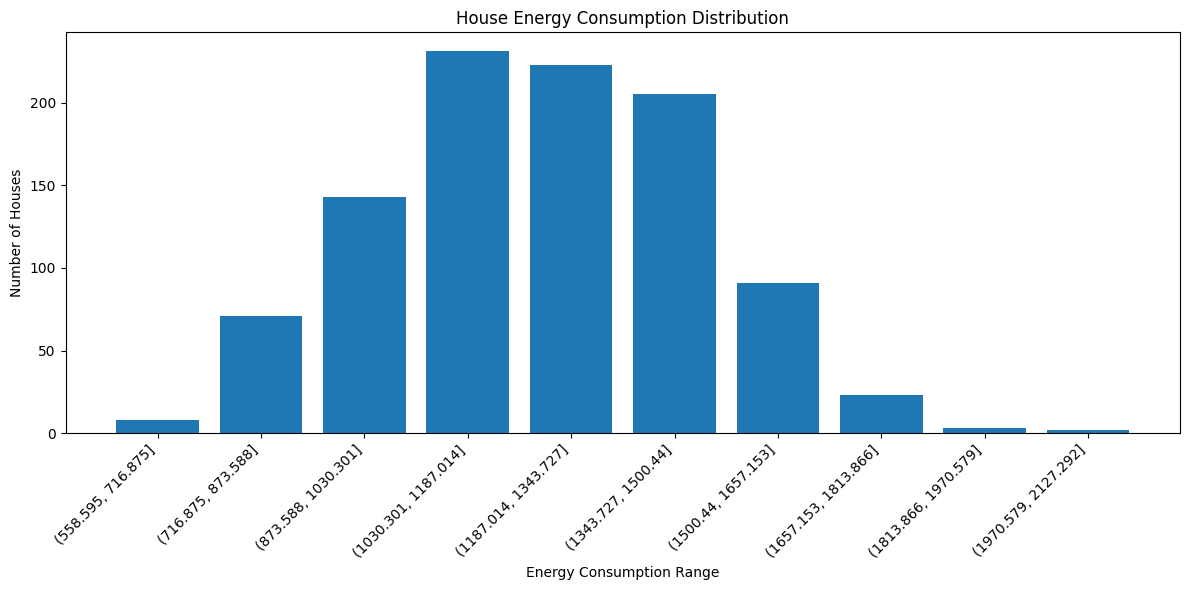

In [18]:
plt.figure(figsize=(12, 6))

# Divide energy consumption into 10 ranges
data["Energy_Range"] = pd.cut(
    data["Energy_Consumption"],
    bins=10
)

# Count houses in each range
energy_counts = data["Energy_Range"].value_counts().sort_index()

# Bar graph
plt.bar(
    range(len(energy_counts)),
    energy_counts.values
)

plt.xlabel("Energy Consumption Range")
plt.ylabel("Number of Houses")
plt.title("House Energy Consumption Distribution")

plt.xticks(
    range(len(energy_counts)),
    [str(x) for x in energy_counts.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [6]:
X = data.drop("Energy_Consumption", axis=1)

y = data["Energy_Consumption"]

print("Input Features:")
print(X.columns)

print("\nTarget:")
print("Energy_Consumption")

Input Features:
Index(['House_Area', 'Number_of_Rooms', 'Number_of_Occupants',
       'Outside_Temperature', 'Humidity', 'Appliance_Usage_Hours',
       'AC_Usage_Hours', 'Lighting_Hours'],
      dtype='object')

Target:
Energy_Consumption


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=15
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [9]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[1036.05647527 1415.64866737 1245.49085947 1166.40506167 1183.38389475
  961.08380778 1442.69566198  889.13191039  866.51615834 1106.78732088]


In [10]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R² Score :", round(r2, 4))

Model Performance
-------------------------
MAE  : 90.38
MSE  : 13400.9
RMSE : 115.76
R² Score : 0.7736


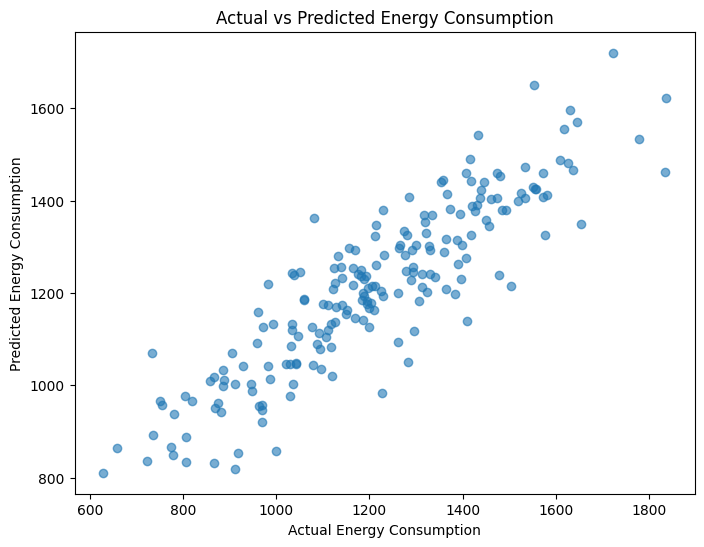

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")

plt.title("Actual vs Predicted Energy Consumption")

plt.show()

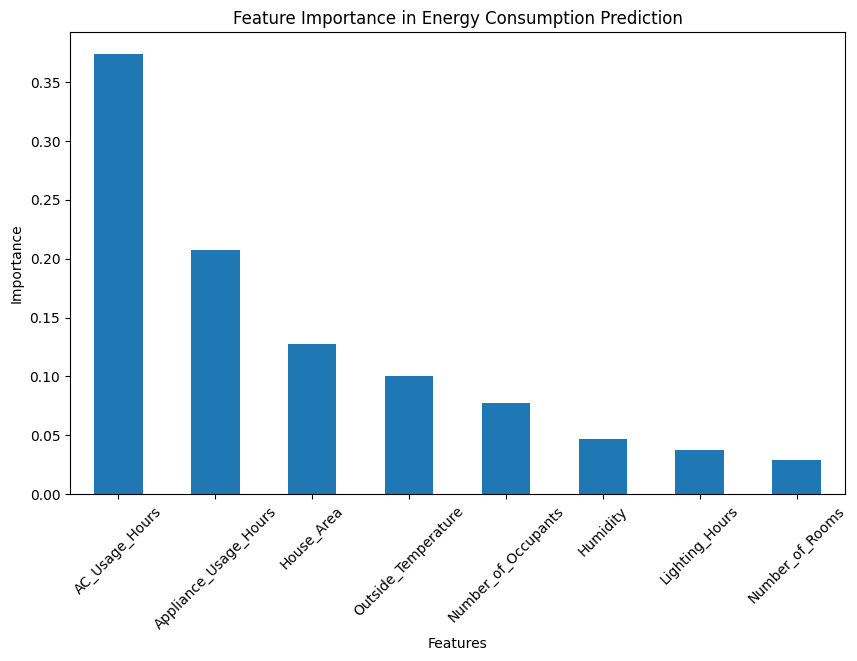

In [13]:

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

importance.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance in Energy Consumption Prediction")

plt.xticks(rotation=45)

plt.show()

In [14]:
new_house = pd.DataFrame({
    "House_Area": [1500],
    "Number_of_Rooms": [4],
    "Number_of_Occupants": [4],
    "Outside_Temperature": [32],
    "Humidity": [65],
    "Appliance_Usage_Hours": [8],
    "AC_Usage_Hours": [5],
    "Lighting_Hours": [6]
})

prediction = model.predict(new_house)

print(
    "Predicted Energy Consumption:",
    round(prediction[0], 2)
)

Predicted Energy Consumption: 1200.71


In [17]:
area = float(input("Enter house area (sq.ft): "))
rooms = int(input("Enter number of rooms: "))
occupants = int(input("Enter number of occupants: "))
temperature = float(input("Enter outside temperature: "))
humidity = float(input("Enter humidity: "))
appliance_hours = float(input("Enter appliance usage hours: "))
ac_hours = float(input("Enter AC usage hours: "))
lighting_hours = float(input("Enter lighting usage hours: "))

user_house = pd.DataFrame({
    "House_Area": [area],
    "Number_of_Rooms": [rooms],
    "Number_of_Occupants": [occupants],
    "Outside_Temperature": [temperature],
    "Humidity": [humidity],
    "Appliance_Usage_Hours": [appliance_hours],
    "AC_Usage_Hours": [ac_hours],
    "Lighting_Hours": [lighting_hours]
})

prediction = model.predict(user_house)[0]

print("\n--------------------------------")
print("Predicted Energy Consumption")
print("--------------------------------")
print(round(prediction, 2))

Enter house area (sq.ft): 1500.0
Enter number of rooms: 4
Enter number of occupants: 4
Enter outside temperature:  32.0 
Enter humidity:  65.0 
Enter appliance usage hours: 8
Enter AC usage hours: 5
Enter lighting usage hours: 6

--------------------------------
Predicted Energy Consumption
--------------------------------
1200.71
